In [21]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [22]:
def dull_razor(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Detect hairs using black-hat
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Adaptive threshold for better hair mask
    thresh = cv2.adaptiveThreshold(
        blackhat, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        15, -5
    )

    # Optional dilation to better capture thin hairs
    thresh = cv2.dilate(thresh, np.ones((3,3), np.uint8))

    # Inpaint original image
    inpainted = cv2.inpaint(img_bgr, thresh, 3, cv2.INPAINT_TELEA)

    return inpainted


In [23]:
def illumination_correction_L(img_bgr, kernel_size=55, alpha=1.5, beta=-0.5):
    """
    Corrects uneven illumination using background subtraction
    Applied ONLY on L channel (LAB color space)
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    bg = cv2.GaussianBlur(l, (kernel_size, kernel_size), 0)
    l_corr = cv2.addWeighted(l, alpha, bg, beta, 0)
    l_corr = np.clip(l_corr, 0, 255).astype(np.uint8)

    lab_corr = cv2.merge((l_corr, a, b))
    return cv2.cvtColor(lab_corr, cv2.COLOR_LAB2BGR)


In [24]:
def clahe_L(img_bgr, clip_limit=0.1, tile_grid_size=(8, 8)):
    """
    Applies CLAHE ONLY on L channel (LAB color space)
    Preserves diagnostic color information
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit,
                            tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)


In [25]:
def preprocess_image(img):
    # 1. Advanced hair removal
    img = dull_razor(img)

    # 2. Illumination correction
    img = illumination_correction_L(img)

    # 3. CLAHE (contrast enhancement)
    img = clahe_L(img)

    return img


In [26]:
def preprocess_dataset(input_root, output_root):

    if not os.path.exists(output_root):
        os.makedirs(output_root)

    classes = [d for d in os.listdir(input_root)
               if os.path.isdir(os.path.join(input_root, d))]

    print(f"Found {len(classes)} class folders")

    for cls in classes:
        cls_input_path = os.path.join(input_root, cls)
        cls_output_path = os.path.join(output_root, cls)

        if not os.path.exists(cls_output_path):
            os.makedirs(cls_output_path)

        image_files = [f for f in os.listdir(cls_input_path)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        print(f"\nProcessing class: {cls} ({len(image_files)} images)")

        for filename in tqdm(image_files, desc=f"{cls}"):
            input_img_path = os.path.join(cls_input_path, filename)
            img = cv2.imread(input_img_path)
            if img is None:
                print(f"⚠️ Skipped unreadable file: {filename}")
                continue
            
            img = cv2.resize(img, (224, 224))
            processed = preprocess_image(img)
            cv2.imwrite(os.path.join(cls_output_path, filename), processed)

    print("\n✅ Dataset Preprocessing Completed Successfully!")


In [27]:
# Run 4
preprocess_dataset("Kaggle-10K", "Kaggle-10K Preprocessed")

Found 2 class folders

Processing class: Benign (5500 images)


Benign: 100%|██████████| 5500/5500 [03:33<00:00, 25.79it/s]



Processing class: malignant (5105 images)


malignant: 100%|██████████| 5105/5105 [03:14<00:00, 26.23it/s]


✅ Dataset Preprocessing Completed Successfully!


In [28]:
# Run 4
preprocess_dataset("Kaggle-3K", "Kaggle-3K Preprocessed")

Found 2 class folders

Processing class: Benign (1800 images)


Benign: 100%|██████████| 1800/1800 [01:35<00:00, 18.90it/s]



Processing class: malignant (1497 images)


malignant: 100%|██████████| 1497/1497 [01:27<00:00, 17.07it/s]


✅ Dataset Preprocessing Completed Successfully!


In [29]:
# Run 1
preprocess_dataset("binary_isic_2017", "binary_isic_2017 Preprocessed")

Found 2 class folders

Processing class: benign (1626 images)


benign:   0%|          | 0/1626 [00:00<?, ?it/s]

benign: 100%|██████████| 1626/1626 [07:17<00:00,  3.71it/s]



Processing class: malignant (374 images)


malignant: 100%|██████████| 374/374 [00:54<00:00,  6.83it/s]


✅ Dataset Preprocessing Completed Successfully!


In [30]:
# Run 2
preprocess_dataset("PH2-dataset", "PH2-dataset Preprocessed")

Found 2 class folders

Processing class: Benign (160 images)


Benign: 100%|██████████| 160/160 [00:15<00:00, 10.59it/s]



Processing class: Malignant (40 images)


Malignant: 100%|██████████| 40/40 [00:04<00:00,  9.92it/s]


✅ Dataset Preprocessing Completed Successfully!


In [31]:
# Run 3
preprocess_dataset("Kaggle-13K", "Kaggle-13K Preprocessed")

Found 2 class folders

Processing class: Benign (7289 images)


Benign: 100%|██████████| 7289/7289 [04:32<00:00, 26.75it/s]



Processing class: Malignant (6590 images)


Malignant: 100%|██████████| 6590/6590 [05:33<00:00, 19.77it/s]


✅ Dataset Preprocessing Completed Successfully!


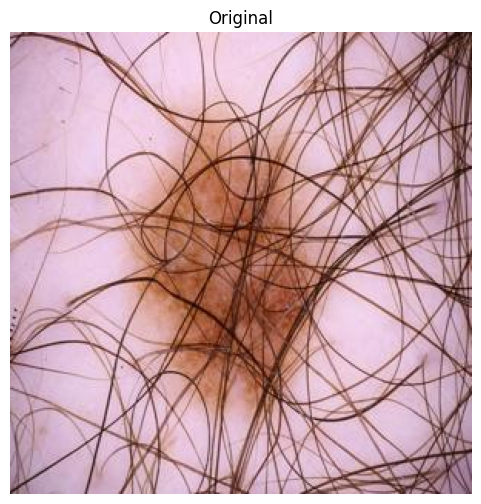

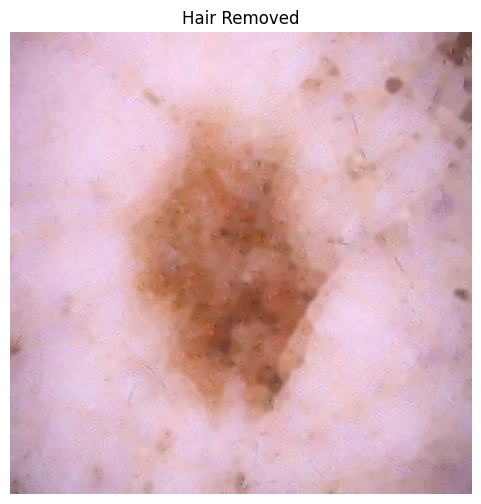

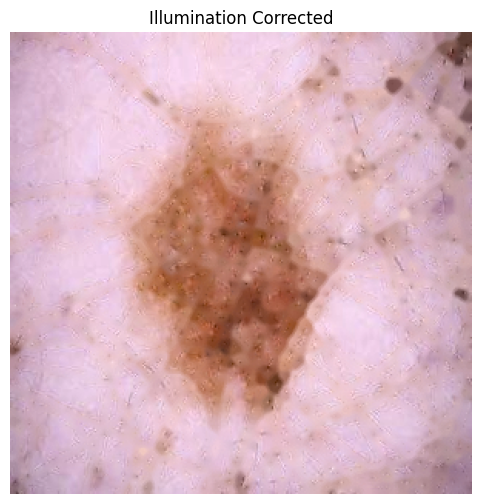

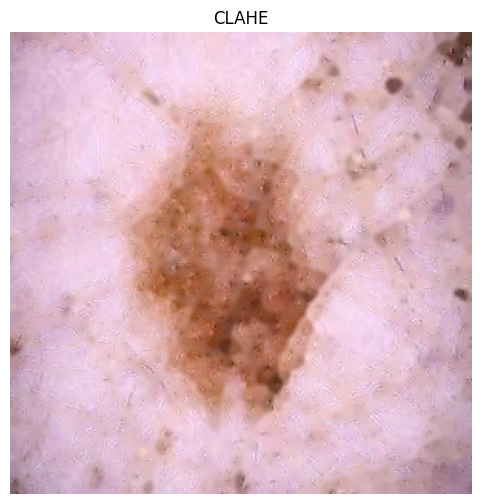

In [32]:
import cv2
import matplotlib.pyplot as plt

# Preprocessing functions
def preprocess_image(img):
    images = [img.copy()]  # original

    # 1. Advanced hair removal
    img_hair_removed = dull_razor(img.copy())
    images.append(img_hair_removed)

    # 2. Illumination correction
    img_ill = illumination_correction_L(img_hair_removed.copy())
    images.append(img_ill)

    # 3. CLAHE (contrast enhancement)
    img = clahe_L(img_ill.copy())

    images.append(img)

    return images

# Path to your single image
image_path = r"C:\Users\Faysal Ahmmed\Desktop\New folder\Kaggle-10K\Benign\melanoma_28.jpg"

# Read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply preprocessing
step_images = preprocess_image(img)

# Titles for each step
titles = ['Original', 'Hair Removed', 'Illumination Corrected', 'CLAHE']

# Display images one by one
for i, (im, title) in enumerate(zip(step_images, titles)):
    plt.figure(figsize=(6, 6))
    plt.imshow(im)
    plt.title(title)
    plt.axis('off')
    plt.show()

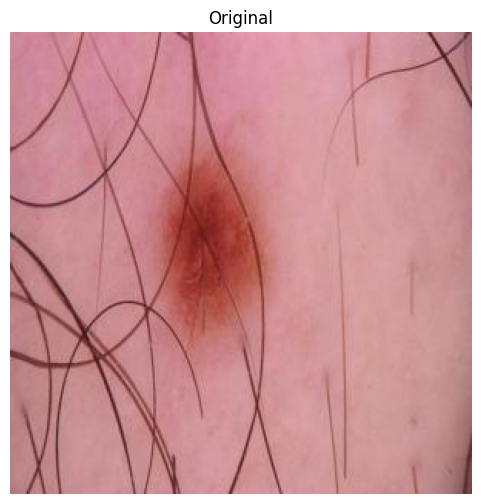

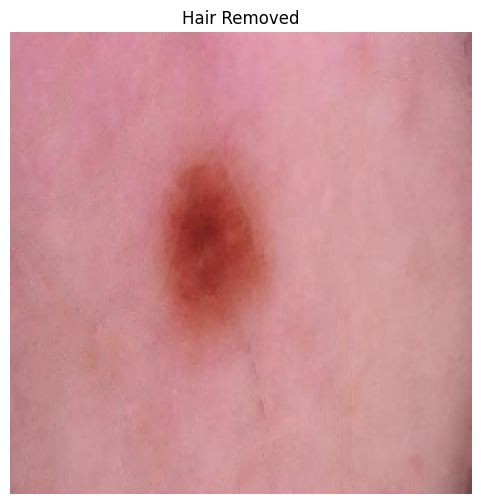

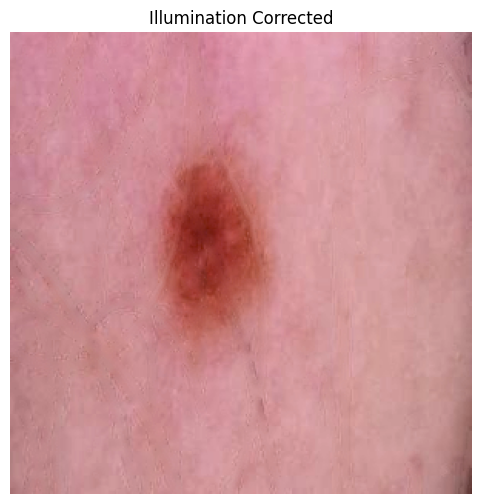

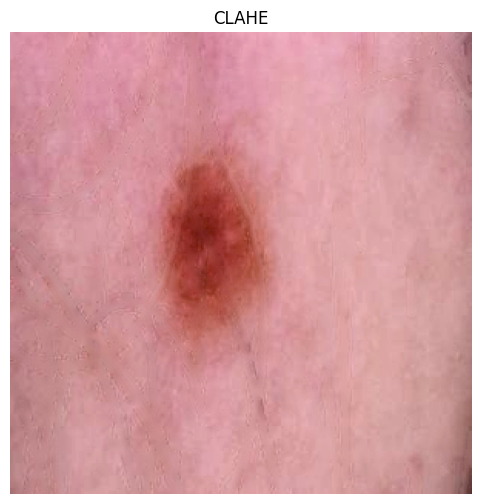

In [33]:
import cv2
import matplotlib.pyplot as plt

# Preprocessing functions
def preprocess_image(img):
    images = [img.copy()]  # original

    # 1. Advanced hair removal
    img_hair_removed = dull_razor(img.copy())
    images.append(img_hair_removed)

    # 2. Illumination correction
    img_ill = illumination_correction_L(img_hair_removed.copy())
    images.append(img_ill)

    # 3. CLAHE (contrast enhancement)
    img = clahe_L(img_ill.copy())

    images.append(img)

    return images

# Path to your single image
image_path = r"C:\Users\Faysal Ahmmed\Desktop\New folder\Kaggle-10K\Benign\melanoma_170.jpg"
# Read image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply preprocessing
step_images = preprocess_image(img)

# Titles for each step
titles = ['Original', 'Hair Removed', 'Illumination Corrected', 'CLAHE']

# Display images one by one
for i, (im, title) in enumerate(zip(step_images, titles)):
    plt.figure(figsize=(6, 6))
    plt.imshow(im)
    plt.title(title)
    plt.axis('off')
    plt.show()